## PARTE 1: NUMPY

¿Cuál es el tamaño en bytes de un array de 1000 elementos de tipo booleano?

In [6]:
import numpy as np
array_bool = np.zeros(1000, dtype=bool)
print(f"Tamaño en bytes: {array_bool.nbytes}")

Tamaño en bytes: 1000


Cree un array cuyos elementos sean los enteros pares en [1,100] y en orden decreciente. Muestre los 10 últimos por pantalla.

In [7]:
pares_decreciente = np.arange(100, 0, -2)
print(pares_decreciente[-10:])

[20 18 16 14 12 10  8  6  4  2]


Dado el array
2 4 5 6
0 3 7 4
8 8 5 2
1 5 6 1
Seleccione con una instrucción el subarray de elementos
0 3 7 4
Después, seleccione el subarray de elementos
2 5
8 5

In [8]:
# 1. Definimos la matriz del ejercicio 3
matriz = np.array([
    [2, 4, 5, 6],
    [0, 3, 7, 4],
    [8, 8, 5, 2],
    [1, 5, 6, 1]
])

# 2. Selección del primer subarray: 0 3 7 4
subarray_1 = matriz[1, :]
print("Subarray 1):")
print(subarray_1)

# 3. Selección del segundo subarray: 2 5 y 8 5 
subarray_2 = matriz[[0, 2], :][:, [0, 2]]
print("\nSubarray 2:")
print(subarray_2)

Subarray 1):
[0 3 7 4]

Subarray 2:
[[2 5]
 [8 5]]


Dados los arrays a = [1, 4, 2, 7] y b = [1, 3, 2, 9],
obtenga la media aritmética de la diferencia (a-b).

In [9]:
a = np.array([1, 4, 2, 7])
b = np.array([1, 3, 2, 9])
media_dif = np.mean(a - b)
print(media_dif)

-0.25


Tengo valores de coordenadas (x, y) en las columnas del array
1.33 4.5
30.0 10.7
70.2 0.5
Agregue a este array las coordenadas (37.1, -3.6).
Muestre en pantalla las dimensiones del nuevo array.

In [10]:
coordenadas = np.array([[1.33, 4.5], [30.0, 10.7], [70.2, 0.5]])
nueva_coordenada = np.array([[37.1, -3.6]])
coordenadas_actualizado = np.append(coordenadas, nueva_coordenada, axis=0)
print(coordenadas_actualizado.shape)

(4, 2)


Copie el array del ejercicio anterior. Traspóngalo (.
Agregue ahora dos nuevos pares de coordenadas: (10.8,3.0) y (35.8, 12.0).

In [15]:
coordenadas_copia = coordenadas_actualizado.copy()
coordenadas_transpuesta = coordenadas_copia.T
nuevas_columnas = np.array([
    [10.8, 35.8], 
    [3.0, 12.0]
])

coordenadas_final = np.concatenate((coordenadas_transpuesta, nuevas_columnas), axis=1)

print("Array transpuesto y actualizado:")
print(coordenadas_final)
print("\nDimensiones finales:", coordenadas_final.shape)

Array transpuesto y actualizado:
[[ 1.33 30.   70.2  37.1  10.8  35.8 ]
 [ 4.5  10.7   0.5  -3.6   3.   12.  ]]

Dimensiones finales: (2, 6)


## Parte 2: Exploración y Minería de Datos:

Con el dataset nucleospoblacion.csv adjunto al laboratorio, luego responda las siguientes preguntas usando pandas y matplotlib.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset
df = pd.read_csv('NucleosPoblacion.csv')

1) ¿Cuántos Municipios tienen más de 100000 habitantes?

In [36]:
municipios_100k = df[df['Poblacion'] > 100000]
print(f"Número de municipios con más de 100k habitantes: {len(municipios_100k)}")

Número de municipios con más de 100k habitantes: 62


2) Realice una gráfica de barras sobre la población de cada ciudad, ordenela de menor a mayor y responda:
a. ¿Cuál es la segunda ciudad más poblada?
b. ¿Qué posición ocupa Granada en el ranking de las ciudades más pobladas?

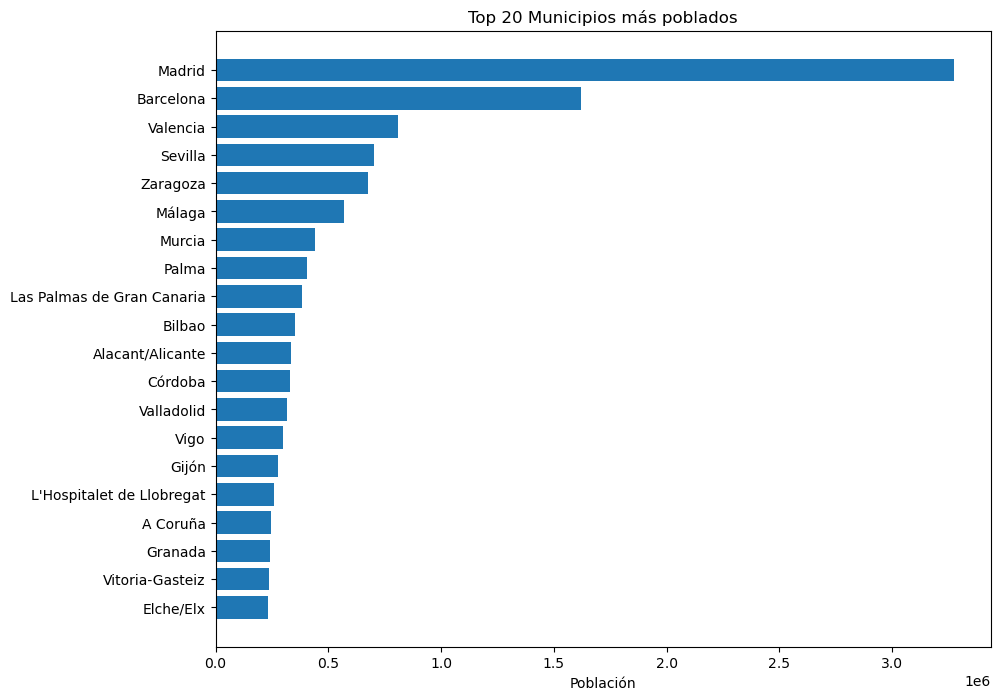

La segunda ciudad más poblada es: Barcelona
Granada ocupa la posición número: 18


In [37]:
df_ordenado = df.sort_values(by='Poblacion', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df_ordenado['Municipio'].tail(20), df_ordenado['Poblacion'].tail(20))
plt.xlabel('Población')
plt.title('Top 20 Municipios más poblados')
plt.show()

df_ranking = df.sort_values(by='Poblacion', ascending=False).reset_index(drop=True)
# a. Segunda ciudad más poblada
segunda_ciudad = df_ranking.iloc[1]['Municipio']
# b. Posición de Granada
posicion_granada = df_ranking[df_ranking['Municipio'] == 'Granada'].index[0] + 1

print(f"La segunda ciudad más poblada es: {segunda_ciudad}")
print(f"Granada ocupa la posición número: {posicion_granada}")

3) ¿Cuántos municipios de Extremadura tienen más de 5000 habitantes?

In [39]:
Extremadura = df[(df['Provincia'].isin(['Cáceres', 'Badajoz'])) & (df['Poblacion'] > 5000)]
print(f"Municipios en Extremadura > 5000 hab: {len(Extremadura)}")

Municipios en Extremadura > 5000 hab: 14


4) ¿Cuál es el municipio situado más al Norte? (Usar el valor de la coordenada "Y" que representa la latitud en grados). Proporcione también la provincia a la que pertenece y su población.

In [40]:
mas_al_norte = df.loc[df['Y'].idxmax()]
print(f"Municipio: {mas_al_norte['Municipio']}, Provincia: {mas_al_norte['Provincia']}, Población: {mas_al_norte['Poblacion']}")

Municipio: Viveiro, Provincia: Lugo, Población: 16211.0


5) Obtenga la media, mediana, desviación estándar, valor máximo y valor mínimo de la población de los municipios de la provincia de Granada.

In [41]:
estad_granada = df[df['Provincia'] == 'Granada']['Poblacion'].agg(['mean', 'median', 'std', 'max', 'min'])
print("Estadísticas de Granada:")
print(estad_granada)

Estadísticas de Granada:
mean       30217.850000
median     17526.000000
std        50355.491715
max       239154.000000
min        10386.000000
Name: Poblacion, dtype: float64


6) Realice un histograma con la población de los Municipios para cada una de las provincias.

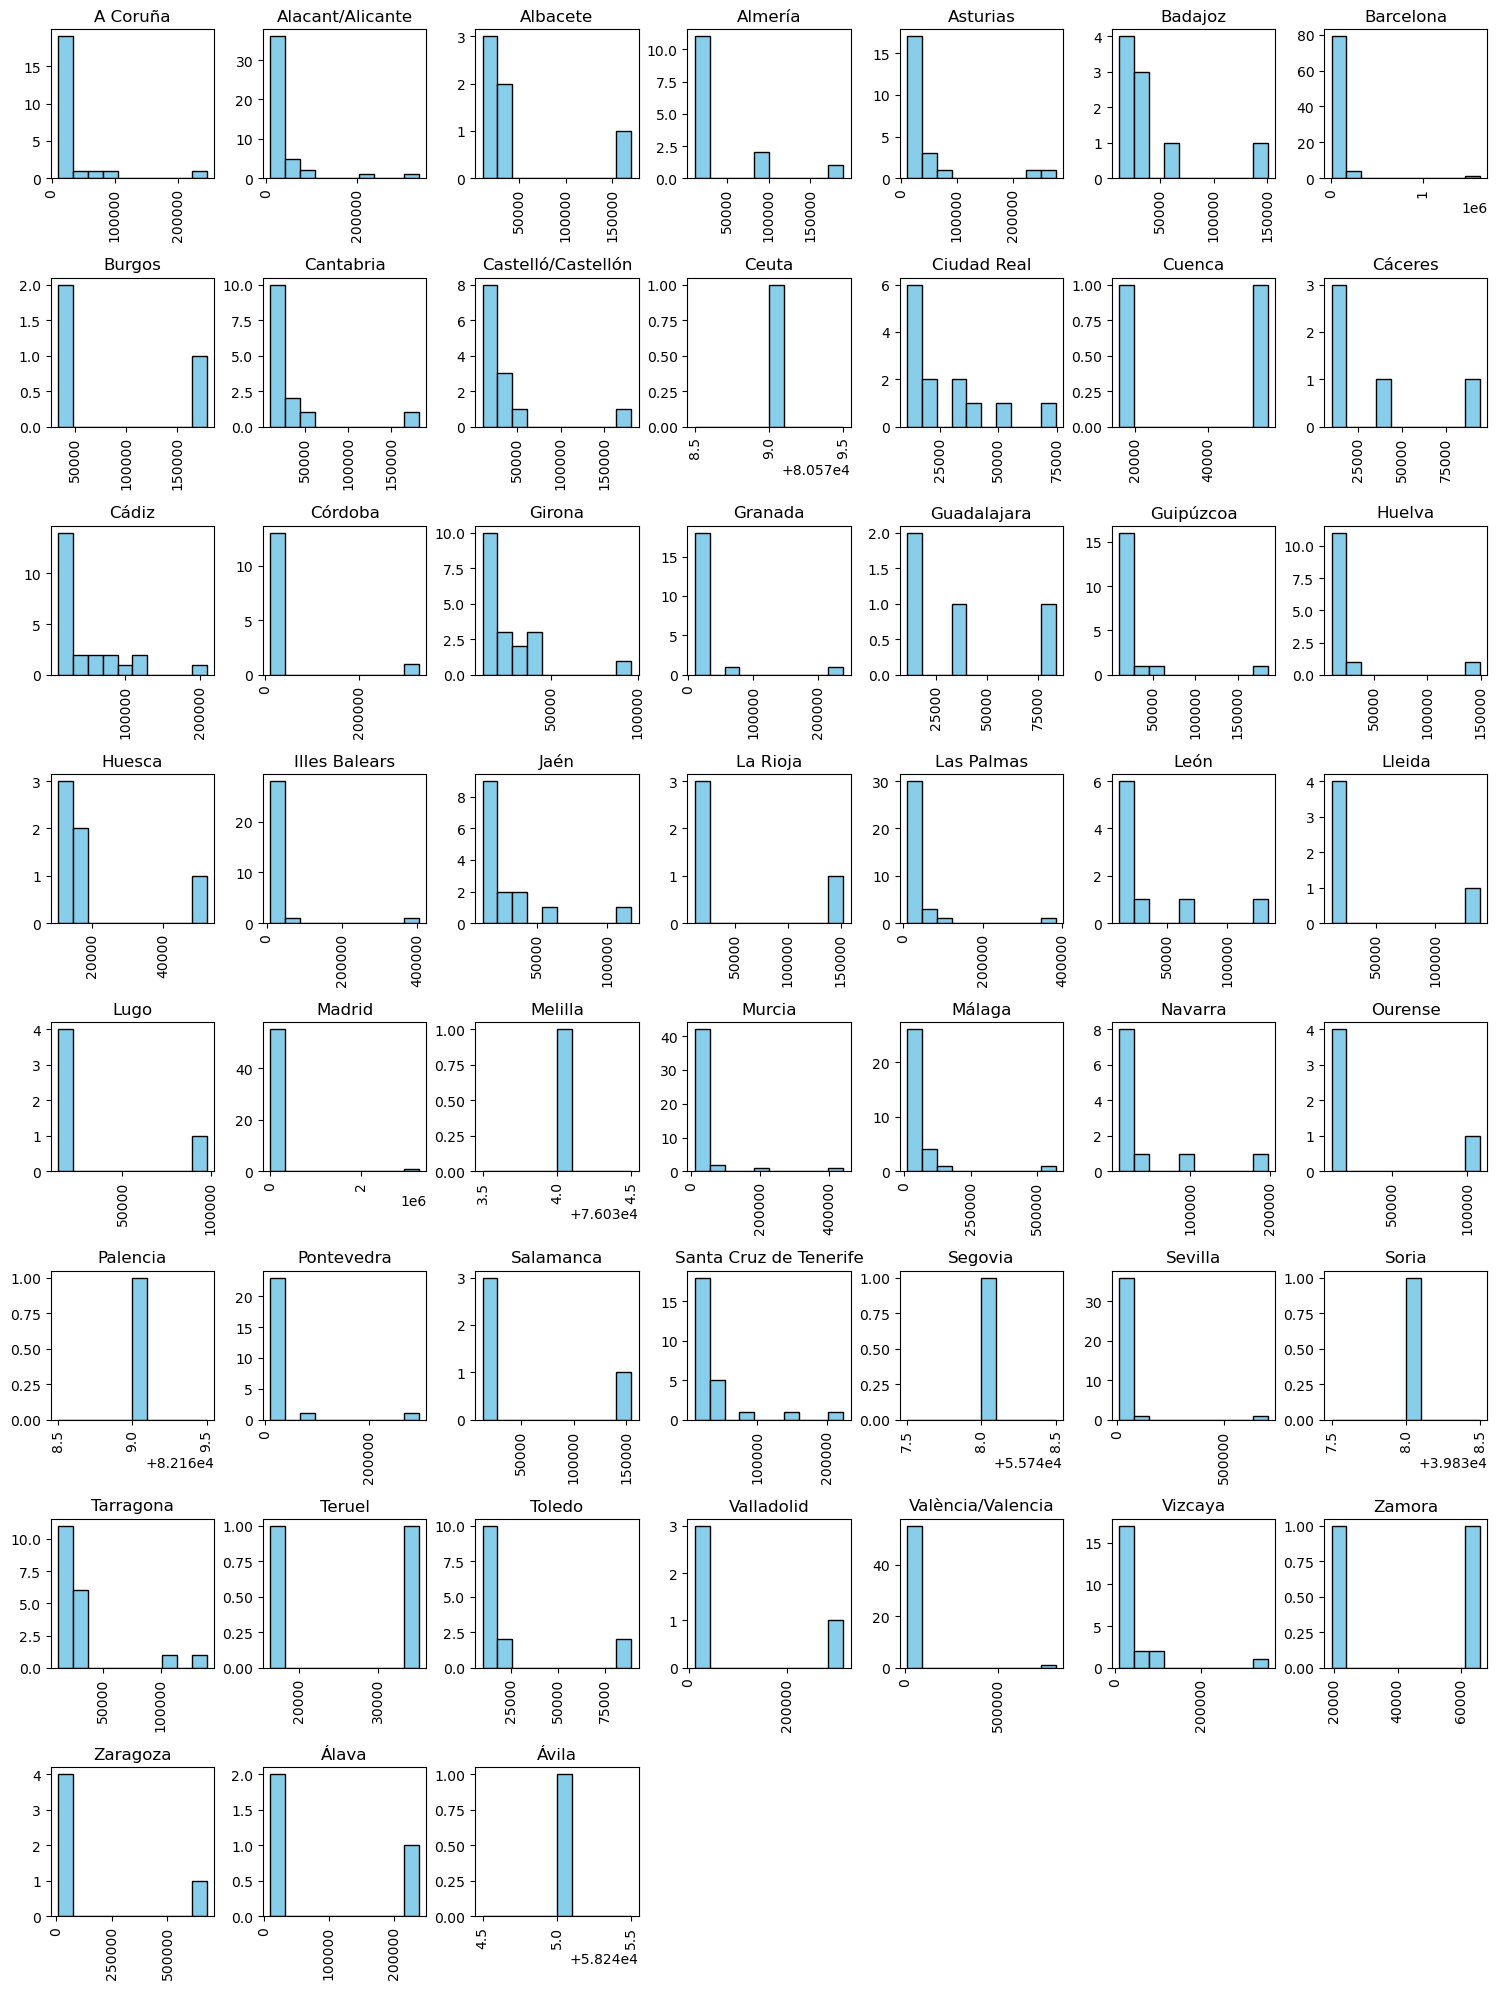

In [44]:
df.hist(column='Poblacion', by='Provincia', figsize=(15, 20), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

7) Seleccione al azar cincuenta municipios diferentes de entre los disponibles en el archivo. Asegúrese de que no se repitan. ¿Luego calcule el promedio de la población y la desviación estándar de esto 50 municipios?

In [45]:
muestra_50 = df.sample(n=50, random_state=42)
print(f"Promedio de la muestra: {muestra_50['Poblacion'].mean()}")
print(f"Desviación estándar de la muestra: {muestra_50['Poblacion'].std()}")

Promedio de la muestra: 36000.82
Desviación estándar de la muestra: 44560.10668917447


8) Dígame los nombres de los Municipios más cercano y más lejano a Madrid. Para ello debe calcular la distancia en todos ellos y Madrid. No considere a Madrid en el análisis ya que la distancia sería cero.

In [46]:
# 1. Obtener coordenadas de Madrid
madrid_coordenadas = df[df['Municipio'] == 'Madrid'][['X', 'Y']].iloc[0]

# 2. Filtrar el dataframe para no incluir a Madrid
df_sin_madrid = df[df['Municipio'] != 'Madrid'].copy()

# 3. Función de distancia
def calcular_distancia(row):
    return np.sqrt((row['X'] - madrid_coordenadas['X'])**2 + (row['Y'] - madrid_coordenadas['Y'])**2)

df_sin_madrid['Distancia_Madrid'] = df_sin_madrid.apply(calcular_distancia, axis=1)

# 4. Resultados
mas_cercano = df_sin_madrid.loc[df_sin_madrid['Distancia_Madrid'].idxmin()]
mas_lejano = df_sin_madrid.loc[df_sin_madrid['Distancia_Madrid'].idxmax()]

print(f"Más cercano a Madrid: {mas_cercano['Municipio']} (Provincia: {mas_cercano['Provincia']})")
print(f"Más lejano a Madrid: {mas_lejano['Municipio']} (Provincia: {mas_lejano['Provincia']})")

Más cercano a Madrid: Pozuelo de Alarcón (Provincia: Madrid)
Más lejano a Madrid: Los Llanos de Aridane (Provincia: Santa Cruz de Tenerife)
